In [1]:
# Basic libraries for file handling, image processing, and numerical operations

import os, cv2, json, torch, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from tqdm import tqdm
from glob import glob
from PIL import Image
from collections import defaultdict, Counter
from scipy.optimize import linear_sum_assignment
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. You're on CPU.")

## DATA DOWNLOAD - Train and Val

In [ ]:
# Download from Google Drive
!gdown https://drive.google.com/uc?id=15Fzosrs96rvXaX-5Xh_ZKb0onDLvIp_I -O /kaggle/working/annotated.tar

In [ ]:
# Extract it
!tar -xvf /kaggle/working/annotated.tar -C /kaggle/working/

In [ ]:
# checking contents
sample_path = "/kaggle/working/annotated/2019_11_05/000002"

# List contents
print("Contents of sample_path:")
print(os.listdir(sample_path))

In [9]:
sequence_paths = sorted(glob("/kaggle/working/annotated/*/*"))
train_sequences = sequence_paths[:7]
val_sequences = sequence_paths[7:]

In [10]:
#check the train and validation sequences
print("Train Sequences:")
for path in train_sequences:
    print(path)

print("\nValidation Sequences:")
for path in val_sequences:
    print(path)

Train Sequences:
/kaggle/working/annotated/2019_11_05/000002
/kaggle/working/annotated/2019_11_05/000009
/kaggle/working/annotated/2019_11_11/000016
/kaggle/working/annotated/2019_11_11/000028
/kaggle/working/annotated/2019_11_11/000036
/kaggle/working/annotated/2019_11_15/000033
/kaggle/working/annotated/2019_11_22/000010

Validation Sequences:
/kaggle/working/annotated/2019_11_28/000113
/kaggle/working/annotated/2019_12_02/000005
/kaggle/working/annotated/2019_12_02/000208
/kaggle/working/annotated/2019_12_10/000060
/kaggle/working/annotated/2019_12_10/000078


## Mask for Standing/Lying

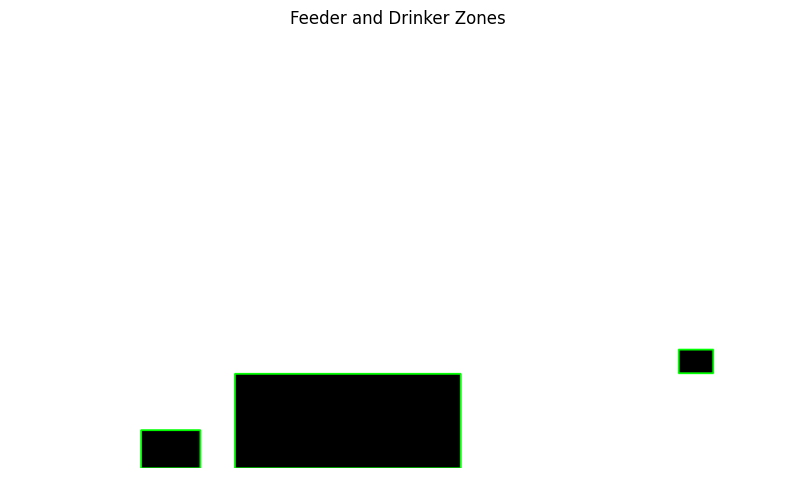

Feeder_ZONE = ((371, 564), (744, 720))
Drinker_L_ZONE = ((216, 657), (314, 720))
Drinker_R_ZONE = ((1104, 524), (1161, 563))


In [2]:
# === Load and preprocess the mask image ===
mask_path = "/kaggle/input/masked/background.jpg"  # Mask created using GIMP by me
image = cv2.imread(mask_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Invert the image so that feeder/drinker regions are white (foreground)
_, binary_mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY_INV)

# === Find top 3 largest blobs (assumed to be feeder and drinkers) ===
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:3]

# === Label and draw bounding boxes ===
zone_names = ["Feeder", "Drinker_L", "Drinker_R"]
zones = []

for name, contour in zip(zone_names, contours):
    x, y, w, h = cv2.boundingRect(contour)
    zones.append(((x, y), (x + w, y + h)))
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image, name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

# === Display annotated image ===
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Feeder and Drinker Zones")
plt.axis("off")
plt.show()

# === Output zone coordinates for use in heuristics ===
for name, coords in zip(zone_names, zones):
    print(f"{name}_ZONE = {coords}")

In [1]:
#Got from above
Feeder_ZONE = ((371, 564), (744, 720))
Drinker_L_ZONE = ((216, 657), (314, 720))
Drinker_R_ZONE = ((1104, 524), (1161, 563))

## Training ResNet for Lying/Standing

In [11]:
# Save the cropped pig images
output_base = "/kaggle/working/train_data"
os.makedirs(f"{output_base}/lying", exist_ok=True)
os.makedirs(f"{output_base}/standing", exist_ok=True)

# === Function to read a specific frame from a video ===
def get_frame(video, frame_number):
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = video.read()
    return frame if success else None

# === Main loop over all training sequences ===
for seq_path in train_sequences:
    print("seq_path:", seq_path)
    json_path = os.path.join(seq_path, "output.json")
    video_path = os.path.join(seq_path, "color.mp4")

    # Load ground-truth annotations from output.json
    with open(json_path, "r") as f:
        data = json.load(f)

    # Open the video file for this sequence
    video = cv2.VideoCapture(video_path)
    seq_name = os.path.basename(seq_path)  # e.g., '000002'

    for pig in data["objects"]:
        pig_id = pig["id"]
        print("Pid Id:", pig_id)
        for entry in pig["frames"]:
            behavior = entry["behaviour"]
            #print("pig_id:", pig_id ,"behaviour:", behavior)

            # We only want to extract 'lying' and 'standing' examples
            if behavior not in ["lying", "standing"]:
                continue

            bbox = entry["bbox"]
            frame_num = entry["frameNumber"] * 3  # Ground-truth frame corresponds to actual video frame 3*f acc to paper

            frame = get_frame(video, frame_num)
            if frame is None:
                continue  # Skip if the frame couldn’t be read

            # Crop the pig from the frame using the bounding box
            x, y, w, h = bbox["x"], bbox["y"], bbox["width"], bbox["height"]
            crop = frame[y:y+h, x:x+w]

            # Save crop to either 'lying/' or 'standing/' folder
            out_name = f"{seq_name}_pig{pig_id}_f{frame_num}.jpg"
            save_path = os.path.join(output_base, behavior, out_name)
            cv2.imwrite(save_path, crop)

    video.release()
    print(f" Finished: {seq_path}")

print("All training crops complete.")

seq_path: /kaggle/working/annotated/2019_11_05/000002
Pid Id: 3
Pid Id: 4
Pid Id: 6
Pid Id: 7
Pid Id: 2
Pid Id: 1
Pid Id: 5
Pid Id: 0
 Finished: /kaggle/working/annotated/2019_11_05/000002
seq_path: /kaggle/working/annotated/2019_11_05/000009
Pid Id: 0
Pid Id: 7
Pid Id: 1
Pid Id: 4
Pid Id: 2
Pid Id: 5
Pid Id: 6
Pid Id: 3
 Finished: /kaggle/working/annotated/2019_11_05/000009
seq_path: /kaggle/working/annotated/2019_11_11/000016
Pid Id: 6
Pid Id: 4
Pid Id: 0
Pid Id: 2
Pid Id: 1
Pid Id: 5
Pid Id: 7
Pid Id: 3
 Finished: /kaggle/working/annotated/2019_11_11/000016
seq_path: /kaggle/working/annotated/2019_11_11/000028
Pid Id: 7
Pid Id: 1
Pid Id: 5
Pid Id: 3
Pid Id: 2
Pid Id: 4
Pid Id: 0
Pid Id: 6
 Finished: /kaggle/working/annotated/2019_11_11/000028
seq_path: /kaggle/working/annotated/2019_11_11/000036
Pid Id: 6
Pid Id: 0
Pid Id: 4
Pid Id: 1
Pid Id: 2
Pid Id: 5
Pid Id: 3
Pid Id: 7
 Finished: /kaggle/working/annotated/2019_11_11/000036
seq_path: /kaggle/working/annotated/2019_11_15/000033
P

In [8]:
base_dir = "/kaggle/working/train_data"
classes = ["lying", "standing"]

for cls in classes:
    folder = os.path.join(base_dir, cls)

    num_images = len([f for f in os.listdir(folder) if f.endswith(".jpg")])
    print(f"{cls}: {num_images} images")

lying: 260 images
standing: 1340 images


In [6]:
# Paths to current images
base_dir = "/kaggle/working/train_data"
output_dir = "/kaggle/working/train_balanced"
os.makedirs(f"{output_dir}/lying", exist_ok=True)
os.makedirs(f"{output_dir}/standing", exist_ok=True)

# Number of images to reach
target_count = 1500

# Define augmentation pipeline
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
])

def augment_images(class_name):
    input_folder = os.path.join(base_dir, class_name)
    output_folder = os.path.join(output_dir, class_name)
    
    # Load existing image paths
    image_paths = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(".jpg")]
    existing_count = len(image_paths)
    needed = target_count - existing_count

    # Copy original images first
    for path in image_paths:
        img = cv2.imread(path)
        filename = os.path.basename(path)
        cv2.imwrite(os.path.join(output_folder, filename), img)

    print(f"Copied {existing_count} original images for '{class_name}'")

    # Perform augmentation
    i = 0
    while i < needed:
        src_path = random.choice(image_paths)
        img = Image.open(src_path).convert("RGB")
        aug_img = augment(img)
        aug_np = np.array(aug_img)

        out_name = f"aug_{i}_{os.path.basename(src_path)}"
        out_path = os.path.join(output_folder, out_name)
        cv2.imwrite(out_path, cv2.cvtColor(aug_np, cv2.COLOR_RGB2BGR))
        i += 1

    print(f"Generated {needed} augmented images for '{class_name}' → total: {target_count}")

# Augment both classes
augment_images("lying")
augment_images("standing")

Copied 260 original images for 'lying'
Generated 1240 augmented images for 'lying' → total: 1500
Copied 1340 original images for 'standing'
Generated 160 augmented images for 'standing' → total: 1500


In [7]:
base_dir = "/kaggle/working/train_balanced"
classes = ["lying", "standing"]

for cls in classes:
    folder = os.path.join(base_dir, cls)
    num_images = len([f for f in os.listdir(folder) if f.endswith(".jpg")])
    print(f"{cls}: {num_images} images")

lying: 1500 images
standing: 1500 images


In [9]:
data_dir = "/kaggle/working/train_balanced"
k_folds = 5
batch_size = 32
epochs = 10
lr = 1e-4
img_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Transforms ===
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Dataset and k-Fold Setup ===
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_accuracies = []
best_acc = 0
best_model_state = None
best_fold = 0

print(f"Total samples: {len(full_dataset)}")

for fold, (train_idx, val_idx) in enumerate(kfold.split(full_dataset)):
    print(f"\nFold {fold+1}/{k_folds}")

    # Subset for this fold
    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size)

    # Model setup
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss:.4f}")

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.2f}%")

    # Save best model state
    if acc > best_acc:
        best_acc = acc
        best_model_state = model.state_dict()
        best_fold = fold

# Save the best model to disk
save_path = f"/kaggle/working/resnet18_best_fold{best_fold+1}.pt"
torch.save(best_model_state, save_path)
print(f"\nBest model saved: Fold {best_fold+1} with {best_acc:.2f}% accuracy → {save_path}")

# Final summary
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"\n🏁 5-Fold Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")

Total samples: 3000

Fold 1/5


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


Epoch 1/10 - Loss: 8.0448
Epoch 2/10 - Loss: 0.5916
Epoch 3/10 - Loss: 0.1358
Epoch 4/10 - Loss: 0.1951
Epoch 5/10 - Loss: 0.5231
Epoch 6/10 - Loss: 0.1436
Epoch 7/10 - Loss: 0.0899
Epoch 8/10 - Loss: 0.0351
Epoch 9/10 - Loss: 0.0205
Epoch 10/10 - Loss: 0.0170
Fold 1 Accuracy: 99.67%

Fold 2/5
Epoch 1/10 - Loss: 8.0500
Epoch 2/10 - Loss: 1.0961
Epoch 3/10 - Loss: 0.2985
Epoch 4/10 - Loss: 0.1433
Epoch 5/10 - Loss: 0.1217
Epoch 6/10 - Loss: 0.0862
Epoch 7/10 - Loss: 0.0404
Epoch 8/10 - Loss: 0.0290
Epoch 9/10 - Loss: 0.0229
Epoch 10/10 - Loss: 0.0121
Fold 2 Accuracy: 99.50%

Fold 3/5
Epoch 1/10 - Loss: 11.1160
Epoch 2/10 - Loss: 0.9497
Epoch 3/10 - Loss: 0.6167
Epoch 4/10 - Loss: 0.5346
Epoch 5/10 - Loss: 0.1476
Epoch 6/10 - Loss: 0.2611
Epoch 7/10 - Loss: 0.1305
Epoch 8/10 - Loss: 0.0381
Epoch 9/10 - Loss: 0.0673
Epoch 10/10 - Loss: 0.0658
Fold 3 Accuracy: 99.17%

Fold 4/5
Epoch 1/10 - Loss: 7.4205
Epoch 2/10 - Loss: 1.1025
Epoch 3/10 - Loss: 0.3613
Epoch 4/10 - Loss: 0.1537
Epoch 5/10

## Validation - To run without training, run below

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_31/851196789.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions

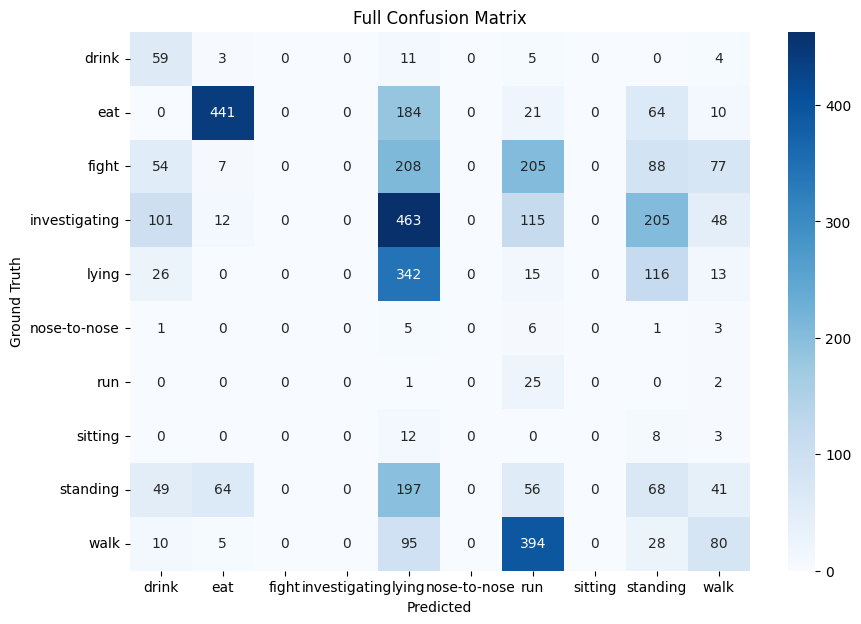

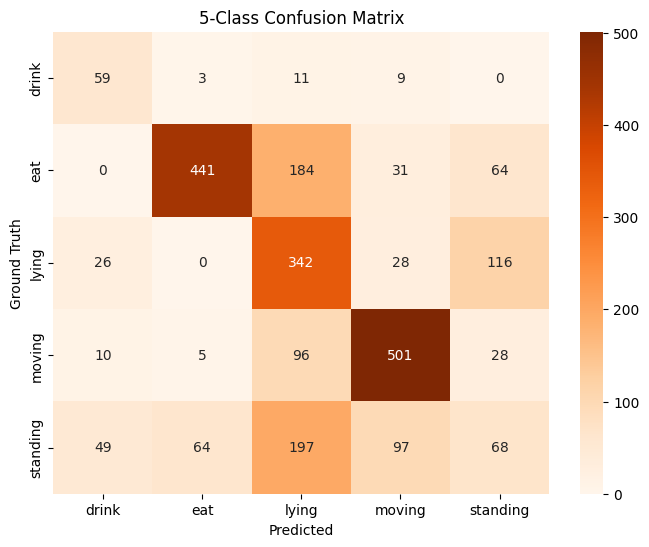

Evaluation complete. Accuracy report written to 'accuracy.txt'


In [16]:
# === Predict on Validation Sequences and Generate Visualizations and Accuracy Summary ===
import json
import cv2
import torch
import numpy as np
import os
from glob import glob
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === Load ResNet18 for lying vs standing ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model_path = "/kaggle/working/resnet18_stand_lie.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

inv_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Feeder_ZONE = ((371, 564), (744, 720))
Drinker_L_ZONE = ((216, 657), (314, 720))
Drinker_R_ZONE = ((1104, 524), (1161, 563))

# Helper functions
def bbox_overlap_ratio(bbox, zone):
    x1, y1, x2, y2 = bbox
    zx1, zy1 = zone[0]
    zx2, zy2 = zone[1]
    ix1 = max(x1, zx1)
    iy1 = max(y1, zy1)
    ix2 = min(x2, zx2)
    iy2 = min(y2, zy2)
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    intersection = iw * ih
    zone_area = (zx2 - zx1) * (zy2 - zy1)
    return intersection / zone_area if zone_area > 0 else 0

def interpolate_bbox(b1, b2, alpha):
    return {
        "x": int(b1["x"] + alpha * (b2["x"] - b1["x"])),
        "y": int(b1["y"] + alpha * (b2["y"] - b1["y"])),
        "width": int(b1["width"] + alpha * (b2["width"] - b1["width"])),
        "height": int(b1["height"] + alpha * (b2["height"] - b1["height"]))
    }

def compute_velocity(b1, b2):
    c1 = (b1["x"] + b1["width"] // 2, b1["y"] + b1["height"] // 2)
    c2 = (b2["x"] + b2["width"] // 2, b2["y"] + b2["height"] // 2)
    return ((c2[0] - c1[0])**2 + (c2[1] - c1[1])**2)**0.5

# === Prediction ===
y_true = []
y_pred = []
sequence_metrics = []
val_sequences = sorted(glob("/kaggle/working/annotated/*/*"))[7:]

for seq_path in val_sequences:
    sequence_name = seq_path.split("/")[-1]
    video_path = os.path.join(seq_path, "color.mp4")
    gt_json_path = os.path.join(seq_path, "output.json")
    my_json_path = os.path.join(seq_path, "my_output.json")

    if not os.path.exists(gt_json_path) or not os.path.exists(video_path):
        continue

    import copy
    with open(gt_json_path) as f:
        gt_data = json.load(f)
    predicted_data = copy.deepcopy(gt_data)

    cap = cv2.VideoCapture(video_path)
    frame_cache = {}
    frame_id = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_cache[frame_id] = frame
        frame_id += 1
    cap.release()

    seq_y_true = []
    seq_y_pred = []

    for obj, pred_obj in zip(gt_data["objects"], predicted_data["objects"]):
        pig_frames = sorted(obj["frames"], key=lambda f: f["frameNumber"])
        annotated_frame_numbers = {f["frameNumber"] for f in pig_frames if f["visible"]}
        interpolated_frames = []

        for i in range(len(pig_frames) - 1):
            f1, f2 = pig_frames[i], pig_frames[i + 1]
            for t in range(f1["frameNumber"], f2["frameNumber"]):
                alpha = (t - f1["frameNumber"]) / (f2["frameNumber"] - f1["frameNumber"])
                bbox = interpolate_bbox(f1["bbox"], f2["bbox"], alpha)
                interpolated_frames.append({"frameNumber": t, "bbox": bbox})

        interpolated_frames.append(pig_frames[-1])

        for j in range(1, len(interpolated_frames)):
            curr = interpolated_frames[j]
            prev = interpolated_frames[j - 1]

            frame_num = curr["frameNumber"]
            bbox = curr["bbox"]
            x, y, w, h = bbox["x"], bbox["y"], bbox["width"], bbox["height"]
            x2, y2 = x + w, y + h
            box_tuple = (x, y, x2, y2)

            velocity = compute_velocity(prev["bbox"], curr["bbox"])

            overlap_feeder = bbox_overlap_ratio(box_tuple, Feeder_ZONE)
            overlap_drinker = max(
                bbox_overlap_ratio(box_tuple, Drinker_L_ZONE),
                bbox_overlap_ratio(box_tuple, Drinker_R_ZONE)
            )

            if overlap_feeder > 0.1 and velocity < 10:
                behavior = "eat"
            elif overlap_drinker > 0.1 and velocity < 7:
                behavior = "drink"
            elif velocity < 2:
                behavior = "lying"
            elif 2 <= velocity <= 5:
                behavior = "standing"
            elif velocity > 20:
                behavior = "run"
            elif 15 < velocity <= 20:
                behavior = "walk"
            else:
                try:
                    crop = frame_cache[frame_num][y:y2, x:x2]
                    if crop.shape[0] == 0 or crop.shape[1] == 0:
                        raise ValueError("Empty crop")
                    input_tensor = inv_transform(crop).unsqueeze(0).to(device)
                    with torch.no_grad():
                        pred = torch.argmax(model(input_tensor), dim=1).item()
                    behavior = "standing" if pred == 0 else "lying"
                except Exception as e:
                    print(f"[ERROR] Frame {frame_num} caused unknown behavior due to: {e}")
                    behavior = "unknown"

            curr.update({
                "visible": True,
                "isGroundTruth": False,
                "behaviour": behavior
            })

        annotated_only = [f for f in interpolated_frames if f["frameNumber"] in annotated_frame_numbers]
        pred_obj["frames"] = annotated_only

    with open(my_json_path, "w") as f:
        json.dump(predicted_data, f, indent=2)

    pred_data = json.load(open(my_json_path))
    TP = FP = FN = 0
    for gt_obj in gt_data["objects"]:
        pred_obj = next((o for o in pred_data["objects"] if o["id"] == gt_obj["id"]), None)
        if not pred_obj:
            continue
        pred_frames = {f["frameNumber"]: f for f in pred_obj["frames"]}
        for gt_frame in gt_obj["frames"]:
            if not gt_frame.get("visible", False):
                continue
            fn = gt_frame["frameNumber"]
            gt_b = gt_frame["behaviour"]
            pred_b = pred_frames.get(fn, {}).get("behaviour")
            if gt_b == "sleep":
                gt_b = "lying"
            if pred_b == "sleep":
                pred_b = "lying"
            if pred_b:
                y_true.append(gt_b)
                y_pred.append(pred_b)
                seq_y_true.append(gt_b)
                seq_y_pred.append(pred_b)
                if pred_b == gt_b:
                    TP += 1
                else:
                    FP += 1
            else:
                FN += 1

    total = TP + FP + FN
    sequence_metrics.append({
        "Sequence": sequence_name,
        "AP (%)": f"{(TP / total) * 100:.2f}%",
        "TP (%)": f"{(TP / (TP + FN)) * 100:.2f}%" if (TP + FN) else "0.00%",
        "FP (%)": f"{(FP / total) * 100:.2f}%",
        "Missed (%)": f"{(FN / total) * 100:.2f}%"
    })

# Visualization
labels = sorted(set(y_true + y_pred))
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Full Confusion Matrix")
plt.show()

# 5-Class Accuracy
beh_map = {"walk": "moving", "run": "moving", "sleep": "lying"}
target_behaviors = {"eat", "drink", "lying", "standing", "moving"}
def normalize_behavior(b):
    return beh_map.get(b, b) if b in target_behaviors or b in beh_map else None

y_true_5, y_pred_5 = [], []
for gt, pred in zip(y_true, y_pred):
    norm_gt = normalize_behavior(gt)
    norm_pred = normalize_behavior(pred)
    if norm_gt and norm_pred:
        y_true_5.append(norm_gt)
        y_pred_5.append(norm_pred)

labels_5 = ["drink", "eat", "lying", "moving", "standing"]
acc_5 = accuracy_score(y_true_5, y_pred_5)
cm_5 = confusion_matrix(y_true_5, y_pred_5, labels=labels_5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_5, annot=True, fmt="d", cmap="Oranges", xticklabels=labels_5, yticklabels=labels_5)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("5-Class Confusion Matrix")
plt.show()

# Write accuracy.txt
with open("/kaggle/working/accuracy.txt", "w") as f:
    f.write(f"Overall Accuracy: {acc * 100:.2f}%\n")
    f.write(f"5-Class Accuracy: {acc_5 * 100:.2f}%\n")
    f.write("\nConfusion Matrix (Full):\n")
    for row in cm:
        f.write(" ".join(map(str, row)) + "\n")
    f.write("\nConfusion Matrix (5-Class):\n")
    for row in cm_5:
        f.write(" ".join(map(str, row)) + "\n")
    f.write("\nPer-Sequence Metrics (AP, TP, FP, Missed):\n")
    df = pd.DataFrame(sequence_metrics)
    f.write(df.to_string(index=False))

print("Evaluation complete. Accuracy report written to 'accuracy.txt'")